## user guide for dump_browse() options

This guide focuses on `pdr`'s dump_browse() and show() functions. For general `pdr` usage take a look at the Eample Jupyter Notebook.

_**Note:** This notebook downloads data from the PDS, so it requires an internet connection. You do not need an internet connection to use `pdr` with data that is already on your computer._

In [1]:
# glob, os, and requests are used to check paths and retrieve remote data in this notebook. you do 
# not need to import them for most uses of pdr.
import glob
import os
# If you're running this locally (not on binder) you'll need to install `requests`. You can do this by activating your
# conda environment and running 'conda install requests', or if you use pip running 'pip install requests' in a terminal
import requests

# importing the pdr module itself is mandatory for most uses of pdr.
import pdr

Example multiband image product from New Horizons

In [2]:
# These are URLs for New Horizons MVIC data and label files
nh_url = 'http://pdssbn.astro.umd.edu/holdings/nh-p_psa-leisa_mvic-5-comp-v1.0/data/color/mvic_0299147977_0x545_sci_pl.img'
nh_lbl = 'http://pdssbn.astro.umd.edu/holdings/nh-p_psa-leisa_mvic-5-comp-v1.0/data/color/mvic_0299147977_0x545_sci_pl.lbl'
# This downloads the data to the current working directory, same way as in Example_JupyterNotebook.ipynb
nh_fn = nh_url.split('/')[-1]
if not os.path.exists(nh_fn):
    req = requests.get(nh_url)
    open(nh_fn, 'wb').write(req.content)
nh_lbl_fn = nh_lbl.split('/')[-1]
if not os.path.exists(nh_lbl):
    reqlbl = requests.get(nh_lbl)
    open(nh_lbl_fn, 'wb').write(reqlbl.content)

In [3]:
# read the file
pluto_multiband = pdr.read(nh_lbl_fn)

# remember dump_browse only works on loaded objects. See that none of the keys/pointers are loaded yet:
pluto_multiband

pdr.Data(/Users/sabrinacurtis/Documents/GitHub/pdr/user_guides/mvic_0299147977_0x545_sci_pl.lbl)
keys=['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']
not yet loaded: ('LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION')

In [4]:
# load the IMAGE pointer
pluto_multiband.load("IMAGE")
pluto_multiband.load("LABEL")

In [5]:
# check that the IMAGE and LABEL pointers have been loaded. Yep!
pluto_multiband

pdr.Data(/Users/sabrinacurtis/Documents/GitHub/pdr/user_guides/mvic_0299147977_0x545_sci_pl.lbl)
keys=['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']
not yet loaded: ('DATA_SET_MAP_PROJECTION',)

By default, writes files to the working directory.

By default, assigns filenames like:
{filename stem}_{object name}.{file extension}

So, for instance, a browse version of a TABLE object referenced from
"jn23a1.lbl" would be written to  "jn23a1_TABLE.csv".

In [6]:
# example with default settings
pluto_multiband.dump_browse()

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


That UserWarning is expected. When an array with 3-4 bands is passed to dump_browse (or show), it tries to make a stacked RGB image from the first three bands, ignoring the 4th band if one is present. This functionality can be overriden, with examples given below.

If outpath is not None, files will be written to the value of outpath
rather than to the working directory.

Useful if there is a specific folder you want to save the browse products to.

In [7]:
# outpath

# checks for an "outputs" subdirectory and creates one if it doesn't exist
cwd = os.getcwd()
outputs_dir = f"{os.getcwd()}/outputs"
if not os.path.exists(outputs_dir):
    os.mkdir(outputs_dir)

# saves the browse image to the "outputs" directory
pluto_multiband.dump_browse(outpath=outputs_dir)

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


If prefix is not None, filenames will begin with the value of prefix
rather than the original filename stem.

Important when saving multiple versions of the same data object because dump_browse writes over outputs with the same name and path without giving a warning message. To avoid accidental overwrites, use custom prefixes.

For this example, the following dump_browse call will output a file named "custom_prefix_IMAGE.jpg"
If we were to load the LABEL object as well, it would output:
- custom_prefix_IMAGE.jpg
- custom_prefix_LABEL.txt

In [8]:
# prefix
pluto_multiband.dump_browse(prefix="custom_prefix", outpath=outputs_dir)

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


- image_format: str = "jpg"  
    Sets image extension which informs the format pillow will save the
    browse image as.

Accepted image file formats are listed in the Pillow handbook:
https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html

In [9]:
# image format
pluto_multiband.dump_browse(outpath=outputs_dir, image_format="png")

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


If purge is True, objects are deleted as soon as they are dumped,
rendering this Data object 'empty' afterward.

Note the IMAGE and LABEL objects are listed as "not yet loaded" after this dump_browse call.

In [16]:
# purge
pluto_multiband.dump_browse(outpath=outputs_dir, purge=True)
print(pluto_multiband)

pdr.Data(/Users/sabrinacurtis/Documents/GitHub/pdr/user_guides/mvic_0299147977_0x545_sci_pl.lbl)
keys=['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']
not yet loaded: ('LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION')


/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


In [11]:
# reload the IMAGE object
pluto_multiband.load("IMAGE")

By default, attempts to apply scaling/offset factors and special
constant masking before writing images. If scaled is False, does not
do that. If scaled == "both", writes both scaled and unscaled
versions, adding "_scaled" and "_unscaled" to their respective
filenames before the file extension. Note that some types of load
operations (like for FITS files) may have already applied scaling
factors, in which case recovering the unscaled image is not possible.

The options are:
- `True` (the default)
- `False`
- `"both"`

In [20]:
# scaled
pluto_multiband.dump_browse(outpath=outputs_dir, scaled="both")

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(
/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


- image_clip: Union[float, tuple[float, float], None] = None  
    Applies a percentile clip to the image at
    clip = (low_percentile, 100-high_percentile).
    If clip is a single value, low_percentile=high_percentile
    in the above formula. If it's a tuple, low_percentile is
    the first value in the tuple.

    The default None value causes 'nice' clipping: it clips the image
    at (1, 1), but if this results in the clipped image containing only
    a single value, it uses the original image instead. Pass 0 if
    absolutely no clipping is desired.

- mask_color: Optional[tuple[int, int, int]] = (0, 255, 255)  
    Allows specification of RGB color for masked arrays (default cyan)

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:354: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


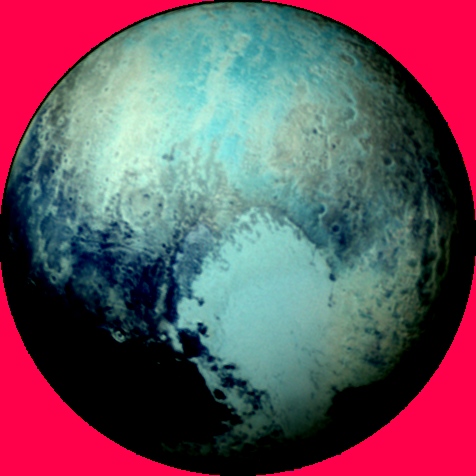

In [62]:
pluto_multiband.show("IMAGE", mask_color=(255, 0, 75), image_clip=(25, 0)) # clip=(low_percentile, 100-high_percentile)

Sometimes an image has 3-4 bands, but we don't want to output a RGB image. Maybe we only want to look at one band, or the image _isn't_ actually a RGB(A) image (e.g. XYZ spatial products). We can use the override_rgba keyword to output images of individual bands instead of a stacked RGB image. 

- Default: override_rgba = False
- This argument has no effect on images that do not have 3-4 bands.

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:368: UserWarning: dumping only band 2 of this image
  warnings.warn(f"dumping only band {middle_ix} of this image")


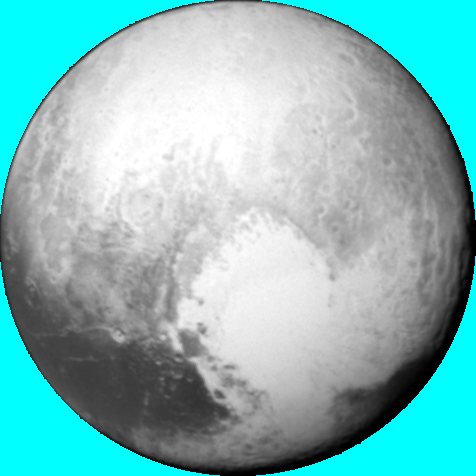

In [85]:
pluto_multiband.show("IMAGE", override_rgba=True)

Note the `UserWarning` above. If a band index is not given, the middle band of a multiband image is output. The `band_ix` keyword is used to get a specific band. Let's use `override_rgb` and `band_ix` to take a look at the CH4 band we've been ignoring up until now.

- default: None
- If there are 3-4 bands in the image and the override_rgba argument is False, this value is ignored.

<sub>(Reminder: python is zero indexed, so the 4th band's index is 3.)</sub>

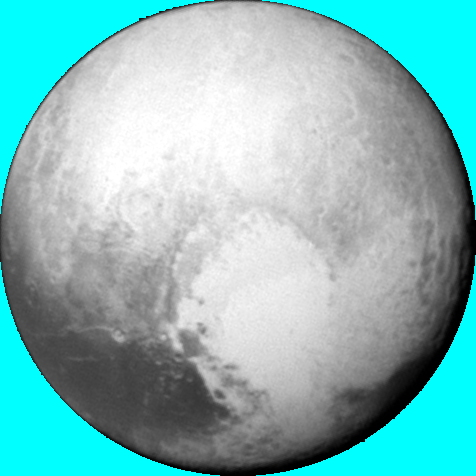

In [88]:
pluto_multiband.show("IMAGE", override_rgba=True, band_ix=3)

In addition to outputing a single band, you can use band_ix to create browse products for _each_ band of a multiband image by setting it equal to "burst".

In [87]:
pluto_multiband.dump_browse("individual_bands", outpath=outputs_dir, override_rgba=True, band_ix="burst")

Sometimes you want to slice along a different axis. Usually the 0 axis is labelled "BAND" when following the PDS3 label schema, but not always. slice_axis is useful for those situations.

In [ ]:
print(pluto_multiband["IMAGE"].shape)

By default we have been slicing along axis 0, which has a length of 4. (Specifically the BLUE, RED, NIR, and CH4 filters of the MVIC instrument.) Axes 1 and 2 have lengths of 476, and form the horizontal and vertical axes of the images we have been outputing.

Slicing along axis 1 or 2 changes the dimensions of the output image.

- slice_axis: int = 0
    Allows specification of which axis to slice along for the
    dump_browse image. The default slices at axis 0 (which is usually
    the axis labelled "BAND").

In [ ]:
pluto_multiband.show("IMAGE", override_rgba=True, slice_axis=1)

In [ ]:
pluto_multiband.show("IMAGE", override_rgba=True, slice_axis=2)

- rgb_channels

In the case of this particular image, the bands are saved within the data file in the order: BLUE, RED, NIR, and CH4. By default dump_browse and show assume the first 3 bands of a 3-4 band image are the red, green, and blue channels respectively.

We can use the rgb_channels argument to select different bands for each channel. In this example we are assigning NIR to the red channel, RED to green, and BLUE to blue.

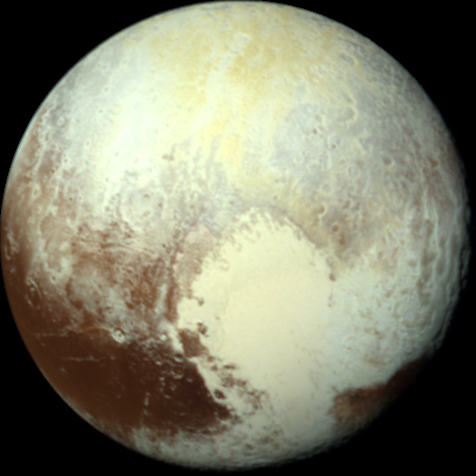

In [71]:
pluto_multiband.show("IMAGE", mask_color=(0, 0, 0), rgb_channels=(2,1,0))

rgb_channels can also be used to create an RGB image from a multiband image with >4 bands by passing it the indices of any 3 bands to use as the R,G,B channels.

In [84]:
pluto_multiband.show("IMAGE", slice_axis=1, rgb_channels=(150,239,360))

- save: bool = True  
    If False, renders images in memory but does not save them to disk.
    Not generally useful when passed to this method except for testing.